Loading Datasets...
Previous dataset loaded. Shape: (5568, 10)
Medications processed. Found records for 1115 patient-hours.
SUCCESS: Final processed file saved to: C:\AINutriCare\Data\Transformed\final_dynamic_icu_dataset.csv
Final Shape: (5568, 16)
Columns: ['hadm_id', 'hour_bin', 'Creatinine', 'Glucose', 'Lactate', 'Potassium', 'Sodium', 'pH', 'HeartRate', 'TotalInput', 'TotalOutput', 'FluidBalance', 'Antibiotics', 'Insulin', 'Sedatives', 'Vasopressors']


C:\Users\saipr\AppData\Local\Temp\ipykernel_23064\3295263918.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med_counts.index, y=med_counts.values, palette='magma')


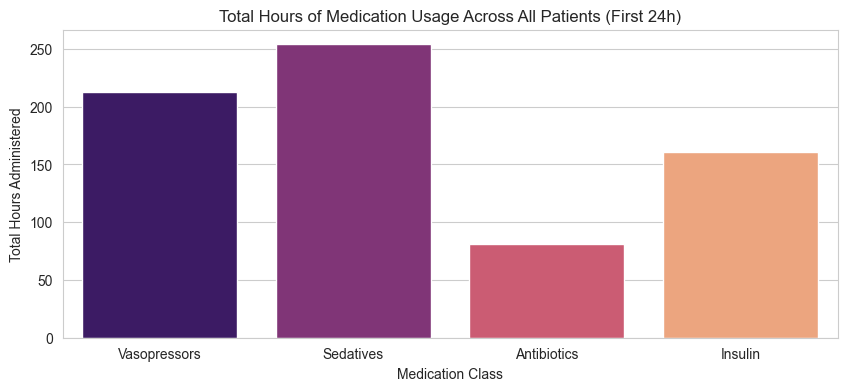

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Path Configuration
raw_dir = r"C:\AINutriCare\Data\Raw"
processed_dir = r"C:\AINutriCare\Data\Transformed"

MED_CLASSES = {
    'Vasopressors': ['norepinephrine', 'epinephrine', 'phenylephrine', 'vasopressin', 'dopamine', 'dobutamine'],
    'Sedatives': ['propofol', 'midazolam', 'fentanyl', 'dexmedetomidine', 'lorazepam'],
    'Antibiotics': ['vancomycin', 'piperacillin', 'tazobactam', 'cefepime', 'meropenem', 'levofloxacin', 'ceftriaxone'],
    'Insulin': ['insulin', 'humalog', 'lantus', 'novolog']
}

def get_raw_path(filename):
    return os.path.join(raw_dir, filename)

def get_processed_path(filename):
    return os.path.join(processed_dir, filename)

try:
    print("Loading Datasets...")
    inputevents = pd.read_csv(get_raw_path('inputevents.csv'), parse_dates=['starttime'])
    d_items = pd.read_csv(get_raw_path('d_items.csv'))
    admissions = pd.read_csv(get_raw_path('admissions.csv'), parse_dates=['admittime'])
    
    # Load from Transformed folder
    base_df = pd.read_csv(get_processed_path('processed_mimic_24h_io_combined.csv'))
    
    if 'hadm_id' in base_df.columns and 'hour_bin' in base_df.columns:
        base_df.set_index(['hadm_id', 'hour_bin'], inplace=True)

    print(f"Previous dataset loaded. Shape: {base_df.shape}")

    if not base_df.empty:
        # --- Prepare InputEvents ---
        inputs_labeled = pd.merge(inputevents, d_items[['itemid', 'label']], on='itemid', how='left')
        inputs_merged = pd.merge(inputs_labeled, admissions[['hadm_id', 'admittime']], on='hadm_id', how='inner')
        
        inputs_merged['hours_in'] = (inputs_merged['starttime'] - inputs_merged['admittime']).dt.total_seconds() / 3600
        meds_24h = inputs_merged[(inputs_merged['hours_in'] >= 0) & (inputs_merged['hours_in'] <= 24)].copy()
        meds_24h['hour_bin'] = np.floor(meds_24h['hours_in']).astype(int)

        # --- Identify Classes (Vectorized) ---
        for med_class, keywords in MED_CLASSES.items():
            pattern = '|'.join(keywords)
            meds_24h[med_class] = meds_24h['label'].str.contains(pattern, case=False, na=False).astype(int)

        # --- Pivot to Time-Series ---
        med_cols = list(MED_CLASSES.keys())
        meds_pivot = meds_24h.pivot_table(index=['hadm_id', 'hour_bin'], values=med_cols, aggfunc='max')
        meds_pivot = meds_pivot.fillna(0)
        
        print(f"Medications processed. Found records for {len(meds_pivot)} patient-hours.")

        # --- Merge with Base Dataset ---
        final_df = base_df.join(meds_pivot)
        final_df[med_cols] = final_df[med_cols].fillna(0)

        # --- Save Final Output to Transformed ---
        output_filename = get_processed_path('final_dynamic_icu_dataset.csv')
        final_df.reset_index(inplace=True)
        final_df.to_csv(output_filename, index=False)
        
        print(f"SUCCESS: Final processed file saved to: {output_filename}")
        print(f"Final Shape: {final_df.shape}")
        print(f"Columns: {final_df.columns.tolist()}")

        # --- Visualization ---
        plt.figure(figsize=(10, 4))
        med_counts = final_df[med_cols].sum()
        sns.barplot(x=med_counts.index, y=med_counts.values, palette='magma')
        plt.title("Total Hours of Medication Usage Across All Patients (First 24h)")
        plt.xlabel("Medication Class")
        plt.ylabel("Total Hours Administered")
        plt.show()

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure all files exist.")